In [2]:
import torch
import torchvision
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from torch.optim.lr_scheduler import StepLR

Dataset and Loader

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),transforms.Normalize(mean=(0.1307,),std=(0.3081,))
])
trainDataset = datasets.MNIST(root="data",train=True,download=True,transform=transform)
testDataset = datasets.MNIST(root="data",train=False,download=True,transform=transform)
trainLoader = DataLoader(trainDataset,batch_size=64,shuffle=True)
testLoader = DataLoader(testDataset,batch_size=64,shuffle=False)   #shuffle is false because we want to see the real images of predicted samples in evaluation

Make model

In [4]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)
model = MNISTModel()
print(model)

MNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


Train and test functions

In [5]:
def trainModel(model,optimizer,scheduler=None,epochs=5):
    lossFunction = nn.CrossEntropyLoss()
    correct = 0
    total = 0
    for epoch in range(epochs):
        model.train()
        totalLoss = 0
        for images,labels in trainLoader:

            optimizer.zero_grad()
            output = model(images)
            loss = lossFunction(output,labels)
            loss.backward()
            optimizer.step()
            totalLoss += loss.item()
            pred = torch.argmax(output,1)
            correct += (pred==labels).sum().item()
            total += labels.size(0)
        if scheduler:
            scheduler.step()
        print(f"epoch {epoch+1}, Avg Loss : {totalLoss/len(images)}")
    print("Train Accuracy : ",correct/total)
def testModel(model):
    model.eval()
    correct = 0
    total = 0
    predictions = []
    targets = []
    with torch.no_grad():
        for images,labels in testLoader:
            output = model(images)
            pred = torch.argmax(output,1)
            correct += (pred==labels).sum().item()
            total += labels.size(0)
            predictions.extend(pred.numpy())
            targets.extend(labels.numpy())
    print("Test Accuracy :",correct/total,"\n\n")
    predictions = np.array(predictions)
    targets = np.array(targets)
    return targets,predictions  

Train and Test model

epoch 1, Avg Loss : 7.8393454916076735
epoch 2, Avg Loss : 3.2589192316518165
epoch 3, Avg Loss : 2.357329752325313
epoch 4, Avg Loss : 1.817657215629879
epoch 5, Avg Loss : 1.4462757629353291
Train Accuracy :  0.9648666666666667
Test Accuracy : 0.978 




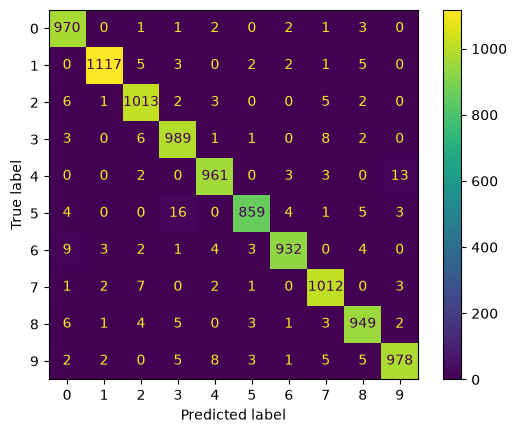

In [6]:
optimizer = Adam(model.parameters(),lr=0.001)
trainModel(model, optimizer, epochs=5)
targets,predictions = testModel(model)
ConfusionMatrixDisplay.from_predictions(targets, predictions)

seeing few images of wrong predictions

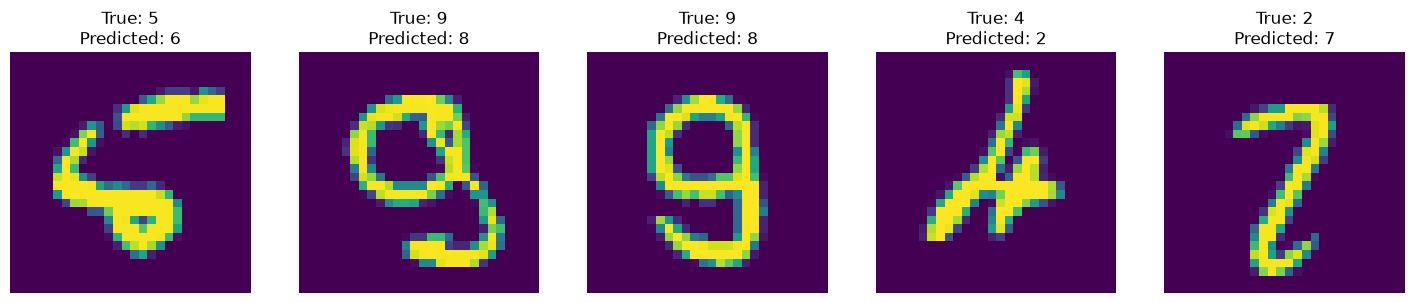

In [7]:
wrong_indices = np.where(predictions != targets)[0]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, indexOfWrong in enumerate(wrong_indices[:5]):
    image, label = testDataset[indexOfWrong]
    axes[i].imshow(image.squeeze())
    axes[i].set_title(f"True: {label}\nPredicted: {predictions[indexOfWrong]}")
    axes[i].axis('off')

plt.show()

Save and Load Model from file

In [13]:
#save
torch.save(model.state_dict(),"mnist_model.pth")

#load
model.load_state_dict(torch.load("mnist_model.pth"))

<All keys matched successfully>

Inference

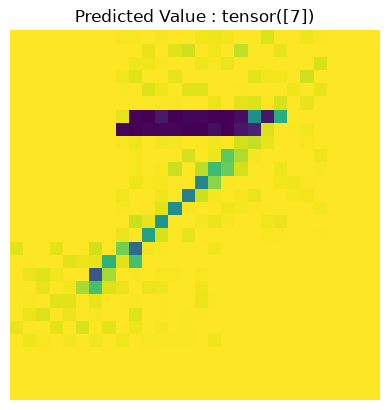

In [12]:
from PIL import Image

image = Image.open("inference.jpg")
image = image.convert("L")
image = transform(image)
image = image.unsqueeze(0)
with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output,dim=1)

plt.imshow(image.squeeze())
plt.title(f"Predicted Value : {prediction}")
plt.axis("off")
plt.show()